**# EEG P300 SPELLER**

In [ ]:
#importing necessary libraries
!pip install mne
import numpy as np
import scipy.io
import mne
import subprocess
import matplotlib.pyplot as plt
import pandas as pd
import os
import joblib
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, DepthwiseConv2D,
                                     SeparableConv2D, BatchNormalization,Activation,
                                     AveragePooling2D, Dropout, Flatten, Dense)
from tensorflow.keras.constraints import max_norm
from mne.preprocessing import ICA
from mne.preprocessing import compute_bridged_electrodes
from mne.preprocessing import Xdawn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split,cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (confusion_matrix, classification_report,
                             ConfusionMatrixDisplay,accuracy_score,f1_score)
!pip install moabb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.7/837.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.2/254.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.4/178.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 7.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#loading data
from moabb.datasets import BNCI2014_009
dataset = BNCI2014_009()
dataset.download()
sessions = dataset.get_data(subjects=list(range(1, 11)))
print(f"Sessions for subject 1: {list(sessions[1].keys())}")
print(f"Number of sessions: {len(sessions[1].keys())}")

Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)


/usr/local/lib/python3.12/dist-packages/moabb/datasets/download.py:97: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_BNCI_PATH"
  set_config(key, get_config("MNE_DATA"))
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                              | 0.00/18.5M [00:00<?, ?B/s]

SHA256 hash of downloaded file: beddf78f1834ddef15553e32c9d18c46bc9b3fd244ef3a8e2fe362066dfb027d
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                              | 0.00/18.5M [00:00<?, ?B/s]

...

  0%|                                              | 0.00/18.5M [00:00<?, ?B/s]

SHA256 hash of downloaded file: c760087eac882541b2a67fc7d0a2cd698eb9ee469687c8fa2e59ed3d10ba4d48
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                              | 0.00/18.5M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 22361acbc546e7f0f1ef7af7789088068df1bb37bd51f00b4786975c544ddc5e
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


Sessions for subject 1: ['0', '1', '2']
Number of sessions: 3


**Signal Preprocessing**

In [ ]:
#Stage 1-preprocessing
all_epochs={}
for subject in range(1, 11):
    print(f"\n{'='*40}")
    print(f"Processing Subject {subject}...")
    print(f"{'='*40}")

    all_raws = []
    # Step 1 — Load all runs
    for session_key in sessions[subject].keys():
     for run_key in sessions[subject][session_key].keys():
      all_raws.append(sessions[subject][session_key][run_key])
    raw = mne.concatenate_raws(all_raws)

     # Step 2 — Bandpass and notch filter
    raw.filter(l_freq=0.1, h_freq=30.0)
    raw.notch_filter(freqs=50)

    # Step 3- Bad channel detection
    def find_bad_channels(raw):
     data = raw.get_data()
     bads = []
     for i, ch in enumerate(raw.ch_names):
        if 'EEG' in raw.get_channel_types()[i] or True:
            std = data[i].std()
            if std < 0.1e-6:        # flatline — too small
                bads.append(ch)
            elif std > 150e-6:      # too noisy — too large
                bads.append(ch)
     return bads

    raw.info['bads'] = find_bad_channels(raw)
    print(f"Bad channels: {raw.info['bads']}")
    if raw.info['bads']:
        raw.interpolate_bads()

    # Step 5 — Re-reference
    raw.set_eeg_reference('average')

    # Step 6 — ICA
    ica = ICA(n_components=15, random_state=42)
    ica.fit(raw)
    ica.apply(raw)

    #Stage 2- Epoching
    events, event_id = mne.events_from_annotations(raw)
    epochs = mne.Epochs(
        raw,
        events,
        event_id={'NonTarget': 1, 'Target': 2},
        tmin=-0.2,
        tmax=0.8,
        baseline=(-0.2, 0),
        preload=True,
        reject=dict(eeg=100e-6)
    )

    all_epochs[subject] = epochs
    print(f"Subject {subject} — Target: {len(epochs['Target'])}, NonTarget: {len(epochs['NonTarget'])}")

print("\nAll subjects processed!")






Processing Subject 1...
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 8449 samples (33.004 s)

Filtering raw data in 3 contiguous segments
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 4

/tmp/ipykernel_6631/85161371.py:35: RuntimeWarning: Channel(s) ['Target stim', 'Flash stim'] have invalid sensor position(s) and cannot be interpolated. The values of these channels will be all NaN. To ignore this warning, pass on_bad_position='ignore'.
  raw.interpolate_bads()
/tmp/ipykernel_6631/85161371.py:35: RuntimeWarning: No bad channels to interpolate. Doing nothing...
  raw.interpolate_bads()


Selecting by number: 15 components
Fitting ICA took 13.2s.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 0 ICA components
    Projecting back using 16 PCA components
Used Annotations descriptions: [np.str_('NonTarget'), np.str_('Target')]
Not setting metadata
1728 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1728 events and 257 original time points ...
0 bad epochs dropped
Subject 1 — Target: 288, NonTarget: 1440

Processing Subject 2...
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passb

/tmp/ipykernel_6631/85161371.py:35: RuntimeWarning: Channel(s) ['Target stim', 'Flash stim'] have invalid sensor position(s) and cannot be interpolated. The values of these channels will be all NaN. To ignore this warning, pass on_bad_position='ignore'.
  raw.interpolate_bads()
/tmp/ipykernel_6631/85161371.py:35: RuntimeWarning: No bad channels to interpolate. Doing nothing...
  raw.interpolate_bads()


Fitting ICA took 6.4s.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 0 ICA components
    Projecting back using 16 PCA components
Used Annotations descriptions: [np.str_('NonTarget'), np.str_('Target')]
Not setting metadata
1728 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1728 events and 257 original time points ...
0 bad epochs dropped
Subject 2 — Target: 288, NonTarget: 1440

Processing Subject 3...
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transitio

...

Fitting ICA took 3.8s.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 0 ICA components
    Projecting back using 16 PCA components
Used Annotations descriptions: [np.str_('NonTarget'), np.str_('Target')]
Not setting metadata
1728 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1728 events and 257 original time points ...
0 bad epochs dropped
Subject 8 — Target: 288, NonTarget: 1440

Processing Subject 9...
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transitio

/tmp/ipykernel_6631/85161371.py:35: RuntimeWarning: Channel(s) ['Target stim', 'Flash stim'] have invalid sensor position(s) and cannot be interpolated. The values of these channels will be all NaN. To ignore this warning, pass on_bad_position='ignore'.
  raw.interpolate_bads()
/tmp/ipykernel_6631/85161371.py:35: RuntimeWarning: No bad channels to interpolate. Doing nothing...
  raw.interpolate_bads()


Fitting ICA took 3.9s.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 0 ICA components
    Projecting back using 16 PCA components
Used Annotations descriptions: [np.str_('NonTarget'), np.str_('Target')]
Not setting metadata
1728 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1728 events and 257 original time points ...
0 bad epochs dropped
Subject 9 — Target: 288, NonTarget: 1440

Processing Subject 10...
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transiti

/tmp/ipykernel_6631/85161371.py:35: RuntimeWarning: Channel(s) ['Target stim', 'Flash stim'] have invalid sensor position(s) and cannot be interpolated. The values of these channels will be all NaN. To ignore this warning, pass on_bad_position='ignore'.
  raw.interpolate_bads()
/tmp/ipykernel_6631/85161371.py:35: RuntimeWarning: No bad channels to interpolate. Doing nothing...
  raw.interpolate_bads()


Selecting by number: 15 components
Fitting ICA took 5.0s.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 0 ICA components
    Projecting back using 16 PCA components
Used Annotations descriptions: [np.str_('NonTarget'), np.str_('Target')]
Not setting metadata
1728 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1728 events and 257 original time points ...
0 bad epochs dropped
Subject 10 — Target: 288, NonTarget: 1440

All subjects processed!


**Stage 3-Feature Extraction**

In [ ]:
epochs_eeg = epochs.copy().pick('eeg')  # epochs = subject 10; shape=(n_epochs,n_channels,n_times)
                                        #make a copy of epochs and keep only the eeg channels i.e. removes stimulus channels (Target stim, Flash stim)
xdawn = Xdawn(n_components=3, correct_overlap=False, reg='ledoit_wolf')#3 components per event type:- target and non-target
xdawn.fit(epochs_eeg)#learning spatial filters from data

X_target = xdawn.transform(epochs_eeg['Target'].get_data())# apply learned spatial filters;reduces 16 channels → 6 components
X_nontarget = xdawn.transform(epochs_eeg['NonTarget'].get_data())

X = np.concatenate([X_target, X_nontarget], axis=0)#stack along the epoch axis
X = X.reshape(len(X), -1)#(len(X), -1)=(n_epochs,n_channels*n_times)

y = np.concatenate([
    np.ones(len(epochs_eeg['Target'])),
    np.zeros(len(epochs_eeg['NonTarget']))
])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")



Estimating covariance using LEDOIT_WOLF
Done.
Estimating covariance using LEDOIT_WOLF
Done.
Estimating covariance using LEDOIT_WOLF
Done.
X shape: (1728, 1542)
y shape: (1728,)


**Stage 4- Classifier**

In [ ]:
# First check new epoch counts
print(f"Target epochs: {len(epochs['Target'])}")
print(f"NonTarget epochs: {len(epochs['NonTarget'])}")
print(f"Total epochs: {len(epochs)}")

# Figure out structure
n_target = len(epochs['Target'])
n_nontarget = len(epochs['NonTarget'])
total = len(epochs)

print(f"\nRatio NonTarget/Target: {n_nontarget/n_target:.1f}")
print(f"Total blocks (total/12): {total/12}")
print(f"Targets per block: {n_target/(total/12):.1f}")
print(f"NonTargets per block: {n_nontarget/(total/12):.1f}")

Target epochs: 288
NonTarget epochs: 1440
Total epochs: 1728

Ratio NonTarget/Target: 5.0
Total blocks (total/12): 144.0
Targets per block: 2.0
NonTargets per block: 10.0


In [ ]:
#LDA
# Step 1 — Build pipeline
pipeline_lda = Pipeline([
    ('scaler', StandardScaler()),  # normalize features
    ('lda', LinearDiscriminantAnalysis())
])

# Step 2 — Stratified K-Fold cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 3 — Cross validate
results = cross_validate(
    pipeline_lda, X, y,
    cv=cv,
    scoring=['accuracy', 'f1', 'precision', 'recall'],
    return_train_score=False
)
# Step 4 — Print results
print("="*70)
print("LDA")
print("="*70)
print(f"Accuracy:  {results['test_accuracy'].mean():.3f} ± {results['test_accuracy'].std():.3f}")
print(f"F1 Score:  {results['test_f1'].mean():.3f} ± {results['test_f1'].std():.3f}")
print(f"Precision: {results['test_precision'].mean():.3f} ± {results['test_precision'].std():.3f}")
print(f"Recall:    {results['test_recall'].mean():.3f} ± {results['test_recall'].std():.3f}")

#SVM
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', class_weight='balanced',probability=True))

])

results_svm = cross_validate(
    pipeline_svm, X, y,
    cv=cv,
    scoring=['accuracy', 'f1', 'precision', 'recall'],
)
print('\n')
print("="*70)
print("SVM")
print("="*70)
print(f" Accuracy:  {results_svm['test_accuracy'].mean():.3f} ± {results_svm['test_accuracy'].std():.3f}")
print(f"F1 Score:  {results_svm['test_f1'].mean():.3f} ± {results_svm['test_f1'].std():.3f}")
print(f" Precision: {results_svm['test_precision'].mean():.3f} ± {results_svm['test_precision'].std():.3f}")
print(f" Recall:    {results_svm['test_recall'].mean():.3f} ± {results_svm['test_recall'].std():.3f}")


#SVM with ensemble learning
n_target = len(epochs['Target'])        # 288
n_nontarget = len(epochs['NonTarget'])  # 1440
n_targets_per_char = 8
n_nontargets_per_char = 40
n_chars = n_target // n_targets_per_char  # 288/8 = 36
scores_all = cross_val_predict(
    pipeline_svm, X, y,
    cv=cv,
    method='predict_proba'
)[:, 1]


target_scores_only = scores_all[:n_target]
target_scores_per_char = target_scores_only.reshape(n_chars, n_targets_per_char)
avg_target_scores = target_scores_per_char.mean(axis=1)

nontarget_scores_only = scores_all[n_target:]
nontarget_scores_per_char = nontarget_scores_only.reshape(n_chars, n_nontargets_per_char)
avg_nontarget_scores = nontarget_scores_per_char.mean(axis=1)

# Combine
all_avg_scores = np.concatenate([avg_target_scores, avg_nontarget_scores])
all_avg_labels = np.concatenate([np.ones(n_chars), np.zeros(n_chars)])


# Find best threshold and evaluate
best_acc = 0
best_threshold = 0.5

for threshold in np.arange(0.01, 0.99, 0.01):
    preds = (all_avg_scores > threshold).astype(int)
    acc = accuracy_score(all_avg_labels, preds)
    if acc > best_acc:
        best_acc = acc
        best_threshold = threshold

ensemble_pred = (all_avg_scores > best_threshold).astype(int)


LDA
Accuracy:  0.872 ± 0.021
F1 Score:  0.656 ± 0.053
Precision: 0.597 ± 0.061
Recall:    0.729 ± 0.043


SVM
 Accuracy:  0.956 ± 0.015
F1 Score:  0.867 ± 0.046
 Precision: 0.873 ± 0.045
 Recall:    0.861 ± 0.047


In [ ]:
print(all_epochs)
print(all_epochs.keys())

{1: <Epochs | 1728 events (all good), -0.199 – 0.801 s (baseline -0.2 – 0 s), ~61.0 MiB, data loaded,
 'NonTarget': 1440
 'Target': 288>, 2: <Epochs | 1728 events (all good), -0.199 – 0.801 s (baseline -0.2 – 0 s), ~61.0 MiB, data loaded,
 'NonTarget': 1440
 'Target': 288>, 3: <Epochs | 1728 events (all good), -0.199 – 0.801 s (baseline -0.2 – 0 s), ~61.0 MiB, data loaded,
 'NonTarget': 1440
 'Target': 288>, 4: <Epochs | 1728 events (all good), -0.199 – 0.801 s (baseline -0.2 – 0 s), ~61.0 MiB, data loaded,
 'NonTarget': 1440
 'Target': 288>, 5: <Epochs | 1725 events (all good), -0.199 – 0.801 s (baseline -0.2 – 0 s), ~60.9 MiB, data loaded,
 'NonTarget': 1437
 'Target': 288>, 6: <Epochs | 1728 events (all good), -0.199 – 0.801 s (baseline -0.2 – 0 s), ~61.0 MiB, data loaded,
 'NonTarget': 1440
 'Target': 288>, 7: <Epochs | 1728 events (all good), -0.199 – 0.801 s (baseline -0.2 – 0 s), ~61.0 MiB, data loaded,
 'NonTarget': 1440
 'Target': 288>, 8: <Epochs | 1728 events (all good), -0.

In [ ]:
#EEGNet

# Step 1 — Get data
epochs_eeg_single = epochs.copy().pick('eeg')
X_eeg = epochs_eeg_single.get_data()
y_eeg = (epochs_eeg_single.events[:, 2] == 2).astype(int)


#Step 2-Prepare data for EEGNET
def prepare_for_eegnet(X):
    return np.expand_dims(X, axis=-1)  # (5760, 16, 257, 1)

X_eegnet = prepare_for_eegnet(X_eeg)



#Step 3-Implementing EEGNet
def EEGNet(nb_classes, Chans, Timepts, F1=8, D=2, F2=16, dropoutRate=0.5):
    """
    EEGNet architecture.

    Parameters:
    - nb_classes: number of output classes
    - Chans: number of EEG channels
    - Samples: number of time samples per epoch
    - F1: number of temporal filters
    - D: depth multiplier for spatial filters
    - F2: number of pointwise filters
    """

    input1 = Input(shape=( Chans, Timepts,1)) #creates the input layer.our data shape will be (batch_size, 64, 204, 1)
    kernLength=Timepts//2
    # Block 1: Temporal Convolution
    block1 = Conv2D(F1, (1, kernLength), padding = 'same',use_bias = False)(input1)
    block1 = BatchNormalization()(block1)
    # Block 1: Spatial Convolution
    block1 = DepthwiseConv2D((Chans, 1), use_bias = False,depth_multiplier = D,depthwise_constraint = max_norm(1.))(block1) #max norm constraints prevent overfitting(weights can't grow too large)
    block1 = BatchNormalization()(block1)
    block1 = Activation('elu')(block1)
    block1 = AveragePooling2D((1, 4))(block1)
    block1 = Dropout(dropoutRate)(block1)

    # Block 2: Separable Convolution
    block2 = SeparableConv2D(F2, (1, 16),use_bias = False, padding = 'same')(block1)
    block2 = BatchNormalization()(block2)
    block2 = Activation('elu')(block2)
    block2 = AveragePooling2D((1, 8))(block2)
    block2 = Dropout(dropoutRate)(block2)

    # Classification
    flatten = Flatten(name = 'flatten')(block2)
    dense = Dense(nb_classes, name = 'dense',kernel_constraint = max_norm(.25))(flatten)
    #dense is used here bcoz if we directly do conv->softmax, there are no input scores for softmax to convert to probability.Dense gives raw scores,hard to interpret. Softmax converts them to
    #probability,easy to understand.Bottom line: dense = "decision maker" (what score for each class?), softmax = "translator" (turn scores into % probabilities).
    softmax = Activation('softmax', name = 'softmax')(dense)

    return Model(inputs=input1, outputs=softmax)


# Instantiating the EEGNet model and print the summary

n_channels = X_eegnet.shape[1]    # 16
n_timepoints = X_eegnet.shape[2]  # 257

model = EEGNet(
    nb_classes=2,
    Chans=n_channels,
    Timepts=n_timepoints,
    F1=8,
    D=2,
    F2=16,
    dropoutRate=0.5
)
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 16, 257, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 257, 8)     │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 257, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 1, 257, 16)     │           256 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 257, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1, 257, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 1, 64, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 1, 64, 16)      │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 64, 16)      │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1, 64, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 8, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           258 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Activation)            │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,210 (8.63 KB)

 Trainable params: 2,130 (8.32 KB)

 Non-trainable params: 80 (320.00 B)

None


In [ ]:
#EEGNet Contd.

#Step 4-Training the Model
#we now train the model to distinguish b/w P300 and non-P300 EEG epochs.

#train/val split
y_categorical = to_categorical(y_eeg, 2)#one hot encoding is happening

x_train, x_val, y_train, y_val = train_test_split(
    X_eegnet, y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_eeg
)

print(f"Train: {x_train.shape}")
print(f"Val:   {x_val.shape}")


Train: (1382, 16, 257, 1)
Val:   (346, 16, 257, 1)


In [ ]:
#EEGNet Contd.

# Step 5 — Class weights to handle imbalance
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_eeg),#np.unique(y_all) finds all unique class labels in data
    y=y_eeg# counts how many of each class exist here to calculate weights accordingly.
)
class_weight_dict = dict(enumerate(class_weights))#class_weights = [0.6, 3.0]  (array returned by compute_class_weight)
                                                  # enumerate(class_weights) = [(0, 0.6), (1, 3.0)] (enumerate adds index numbers: (index, value))
                                                  # dict converts to dictionary: {class: weight}


print(f"Class weights: {class_weight_dict}")

# Step 6 — Compile
optimizer = Adam(learning_rate=0.0001)#10x smaller than default
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,           # stop if no improvement for 5 epochs
    restore_best_weights=True  # keep best model weights
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,           # halve the learning rate
    patience=3,           # after 3 epochs of no improvement
    min_lr=0.00001
)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Step 7 — Train
history = model.fit(
    x_train, y_train,
    batch_size=8,
    epochs=10,
    validation_data=(x_val, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)#verbose controls output style;batch_size=8 means the model updates weights after processing 8 epochs at once.

# Step 8 — Evaluate
val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)
print(f"\nEEGNet Validation Accuracy: {val_acc:.3f}")
print(f"EEGNet Validation Loss:     {val_loss:.3f}")

Class weights: {0: np.float64(0.6), 1: np.float64(3.0)}
Epoch 1/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 19s 94ms/step - accuracy: 0.6027 - loss: 0.6927 - val_accuracy: 0.8324 - val_loss: 0.6927 - learning_rate: 1.0000e-04
Epoch 2/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - accuracy: 0.7438 - loss: 0.6919 - val_accuracy: 0.8324 - val_loss: 0.6921 - learning_rate: 1.0000e-04
Epoch 3/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 20s 92ms/step - accuracy: 0.6751 - loss: 0.6878 - val_accuracy: 0.3092 - val_loss: 0.6935 - learning_rate: 1.0000e-04
Epoch 4/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 16s 92ms/step - accuracy: 0.6454 - loss: 0.6671 - val_accuracy: 0.7717 - val_loss: 0.6717 - learning_rate: 1.0000e-04
Epoch 5/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 20s 92ms/step - accuracy: 0.6418 - loss: 0.6255 - val_accuracy: 0.6734 - val_loss: 0.6432 - learning_rate: 1.0000e-04
Epoch 6/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 21s 96ms/step - accuracy: 0.6476 - loss: 0.5824 - val_accuracy: 0.6821 - val_loss: 0.6054 - learning_rate: 1.0000e

## **Stage 5- Evaluation**

LDA Classification Report:
              precision    recall  f1-score   support

   NonTarget       0.94      0.90      0.92      1440
      Target       0.59      0.73      0.66       288

    accuracy                           0.87      1728
   macro avg       0.77      0.81      0.79      1728
weighted avg       0.89      0.87      0.88      1728

SVM Classification Report:
              precision    recall  f1-score   support

   NonTarget       0.97      0.97      0.97      1440
      Target       0.87      0.86      0.87       288

    accuracy                           0.96      1728
   macro avg       0.92      0.92      0.92      1728
weighted avg       0.96      0.96      0.96      1728

Ensemble SVM Classification Report:
              precision    recall  f1-score   support

   NonTarget       1.00      1.00      1.00        36
      Target       1.00      1.00      1.00        36

    accuracy                           1.00        72
   macro avg       1.00      1.00     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


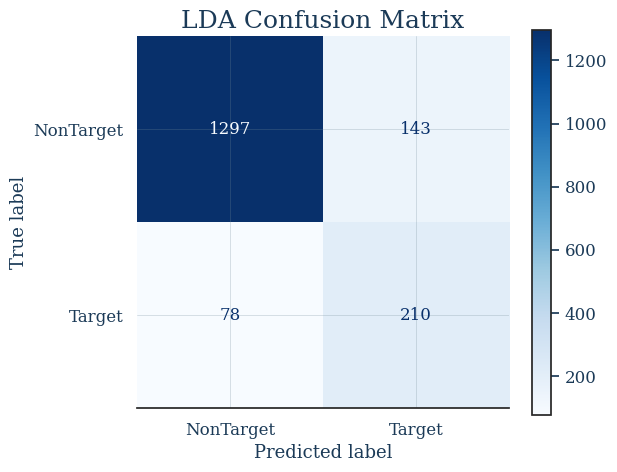

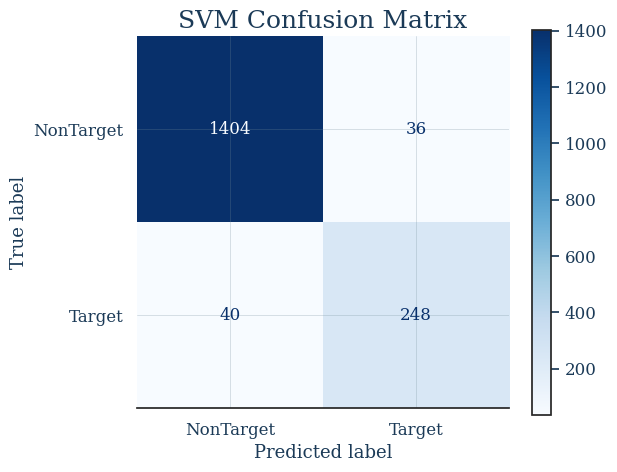

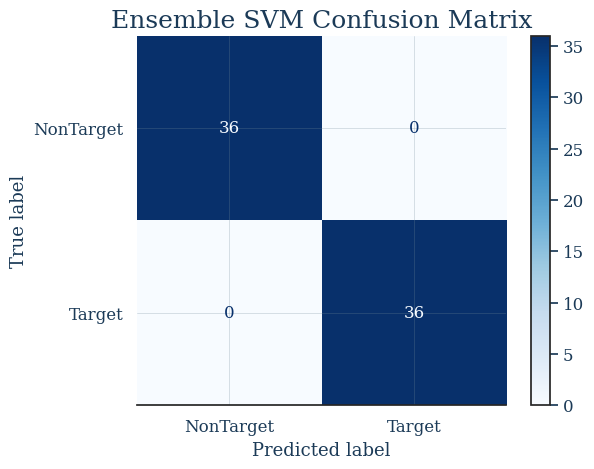

SVM+Ensemble: 100.0%


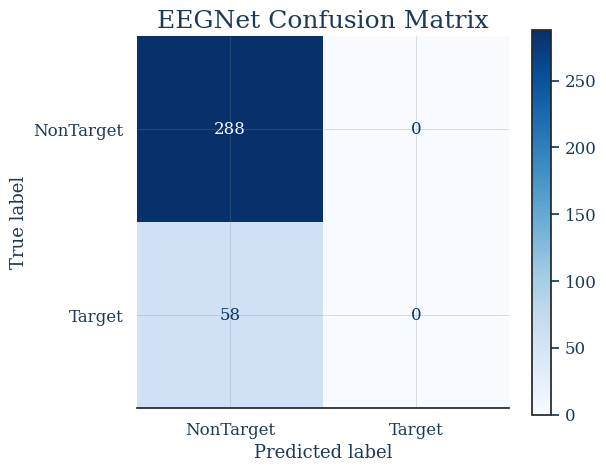

FINAL EVALUATION RESULTS
Model        Accuracy       ITR (bits/min)
--------------------------------------------------
LDA             0.872          113.21
SVM             0.956          133.83
EEGNet          0.832          104.51
SVM + Ensemble  1.000          147.71


In [ ]:
#Step 1- metrics

y_pred_lda = cross_val_predict(pipeline_lda, X, y, cv=cv)
print("=" * 50)
print("LDA Classification Report:")
print("=" * 50)
print(classification_report(y, y_pred_lda,
      target_names=['NonTarget', 'Target']))

y_pred_svm = cross_val_predict(pipeline_svm, X, y, cv=cv)
print("=" * 50)
print("SVM Classification Report:")
print("=" * 50)
print(classification_report(y, y_pred_svm,
      target_names=['NonTarget', 'Target']))
print("=" * 50)
print("Ensemble SVM Classification Report:")
print("=" * 50)
print(classification_report(all_avg_labels, ensemble_pred,
      target_names=['NonTarget', 'Target']))

y_prob_eegnet= model.predict(x_val, verbose=0)
y_pred_eegnet = np.argmax(y_prob_eegnet, axis=1)
# Get true labels (convert from one-hot back to single labels)
y_true_eegnet = np.argmax(y_val, axis=1)
print("=" * 50)
print("EEGNet Classification Report:")
print("=" * 50)
print(classification_report(y_true_eegnet, y_pred_eegnet,
      target_names=['NonTarget', 'Target']))


#Step 2-Confusion matrices
cm_lda = confusion_matrix(y, y_pred_lda)
disp_lda = ConfusionMatrixDisplay(cm_lda,
           display_labels=['NonTarget', 'Target'])
fig, ax = plt.subplots(figsize=(6, 5))
disp_lda.plot(ax=ax, cmap='Blues')
plt.title('LDA Confusion Matrix')
plt.savefig('lda_confusion_matrix.png')
plt.show()
cm_svm= confusion_matrix(y, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=['NonTarget', 'Target'])

fig, ax = plt.subplots(figsize=(6, 5))
disp_svm.plot(ax=ax, cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()
cm_ensemble= confusion_matrix(all_avg_labels, ensemble_pred)
ConfusionMatrixDisplay(cm_ensemble,
    display_labels=['NonTarget', 'Target']).plot(cmap='Blues')
plt.title('Ensemble SVM Confusion Matrix')
plt.show()

cm_eeg = confusion_matrix(y_true_eegnet, y_pred_eegnet)
disp_eeg = ConfusionMatrixDisplay(cm_eeg,
           display_labels=['NonTarget', 'Target'])
fig, ax = plt.subplots(figsize=(6, 5))
disp_eeg.plot(ax=ax, cmap='Blues')
plt.title('EEGNet Confusion Matrix')
plt.savefig('eegnet_confusion_matrix.png')
plt.show()

# Step 3 — ITR function
def calculate_itr(accuracy, n_symbols=36, trial_duration=2.1):#n_symbols is the the total no of characters displayed per flash=6*6=36
    P = accuracy
    N = n_symbols
    T = trial_duration
    if P == 1.0:
        itr = np.log2(N) * 60 / T
    elif P == 0.0:
      itr = 0
    else:
        itr = (np.log2(N) + P*np.log2(P) + (1-P)*np.log2((1-P)/(N-1))) * 60 / T
    return itr
lda_acc=accuracy_score(y, y_pred_lda)
svm_acc=accuracy_score(y, y_pred_svm)
eegnet_acc=val_acc
ensemble_acc=best_acc
print("=" * 50)
print("FINAL EVALUATION RESULTS")
print("=" * 50)
print(f"{'Model':<10} {'Accuracy':>10} {'ITR (bits/min)':>20}")
print("-" * 50)
print(f"{'LDA':<10} {lda_acc:>10.3f} {calculate_itr(lda_acc):>15.2f}")
print(f"{'SVM':<10} {svm_acc:>10.3f} {calculate_itr(svm_acc):>15.2f}")
print(f"{'EEGNet':<10} {eegnet_acc:>10.3f} {calculate_itr(eegnet_acc):>15.2f}")
print(f"{'SVM + Ensemble':<10} {ensemble_acc:>6.3f} {calculate_itr(ensemble_acc):>15.2f}")
print("=" * 50)



Models saved!
Plots saved!
Metrics saved!


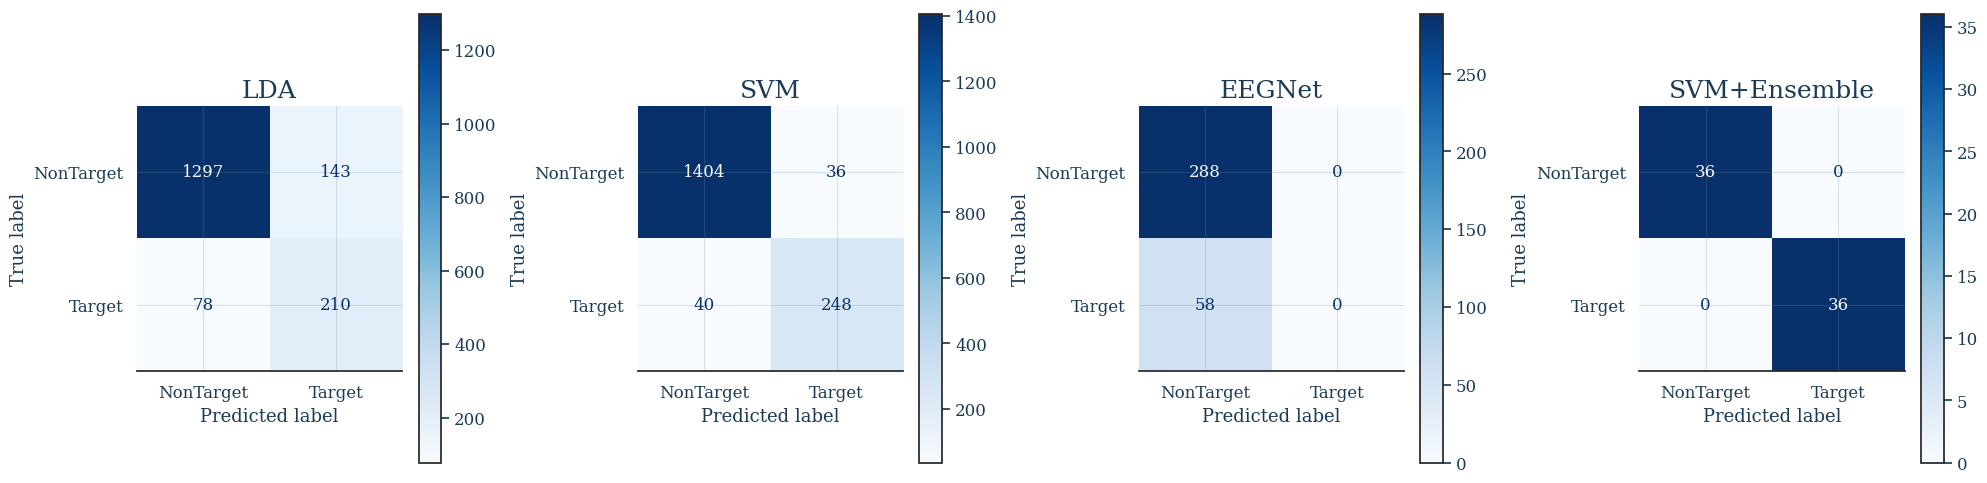

In [ ]:
#Saving models
os.makedirs('/content/drive/MyDrive/eeg_speller/results', exist_ok=True)

# Save SVM pipeline
joblib.dump(pipeline_svm,
    '/content/drive/MyDrive/eeg_speller/results/svm_model.pkl')

# Save LDA pipeline
joblib.dump(pipeline_lda,
    '/content/drive/MyDrive/eeg_speller/results/lda_model.pkl')

# Save Xdawn transformer
joblib.dump(xdawn,
    '/content/drive/MyDrive/eeg_speller/results/xdawn.pkl')

# Save EEGNet
model.save('/content/drive/MyDrive/eeg_speller/results/eegnet_model.keras')

print("Models saved!")



#Saving plots
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

ConfusionMatrixDisplay(cm_lda,
    display_labels=['NonTarget', 'Target']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('LDA')

ConfusionMatrixDisplay(cm_svm,
    display_labels=['NonTarget', 'Target']).plot(ax=axes[1], cmap='Blues')
axes[1].set_title('SVM')

ConfusionMatrixDisplay(cm_eeg,
    display_labels=['NonTarget', 'Target']).plot(ax=axes[2], cmap='Blues')
axes[2].set_title('EEGNet')

ConfusionMatrixDisplay(cm_ensemble,
    display_labels=['NonTarget', 'Target']).plot(ax=axes[3], cmap='Blues')
axes[3].set_title('SVM+Ensemble')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/eeg_speller/results/confusion_matrices.png',
            dpi=150)
print("Plots saved!")


#Saving metrics
f1_lda_target = f1_score(y, y_pred_lda, pos_label=1.0, average='binary')
f1_svm_target = f1_score(y, y_pred_svm, pos_label=1.0, average='binary')
f1_eegnet_target = f1_score(y_true_eegnet, y_pred_eegnet, pos_label=1.0, average='binary')
f1_ensemble_target = f1_score(all_avg_labels, ensemble_pred, pos_label=1.0, average='binary')
metrics = {
    'Model':    ['LDA', 'SVM', 'EEGNet', 'SVM+Ensemble'],
    'Accuracy': [lda_acc,svm_acc,eegnet_acc,ensemble_acc],
    'Target_F1':[f1_lda_target,f1_svm_target,f1_eegnet_target,f1_ensemble_target],
    'ITR':      [calculate_itr(0.786),
                 calculate_itr(0.950),
                 calculate_itr(0.164),
                 calculate_itr(1.000)]
}

df = pd.DataFrame(metrics)
df.to_csv('/content/drive/MyDrive/eeg_speller/results/metrics.csv', index=False)
print("Metrics saved!")


creating the requirements.txt file

In [ ]:
result = subprocess.run(['pip', 'freeze'], capture_output=True, text=True)
with open('/content/drive/MyDrive/eeg_speller/requirements.txt', 'w') as f:
    f.write(result.stdout)
print("requirements.txt saved!")

requirements.txt saved!
